# Yields 

This notebook uses `treasury_quotes_2025-04-30.xlsx`.

**Important data note:** In the uploaded workbook, `selected quotes` contains only 20 Treasury notes. It contains no bills, TIPS, bonds, or missing YTM values. Therefore:

- Section 1.2 uses `selected quotes`, exactly as instructed.
- Section 2 uses the full `quotes` sheet so the TIPS exclusion, missing-YTM analysis, and T-bill discount-yield calculation are possible.

In [41]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import fsolve

def locate_file(filename):
    for path in [Path(filename), Path("data") / filename, Path("/mnt/data") / filename]:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}.")

def bond_price(face, coupon_rate, ytm, years):
    periods = int(round(2 * years))
    coupon = face * coupon_rate / 2
    return (
        sum(coupon / (1 + ytm / 2) ** i for i in range(1, periods + 1))
        + face / (1 + ytm / 2) ** periods
    )

def solve_ytm(price, face, coupon_rate, years):
    objective = lambda y: bond_price(face, coupon_rate, y.item(), years) - price
    return float(fsolve(objective, x0=np.array([0.04]))[0])

file_path = locate_file("treasury_quotes_2025-04-30.xlsx")

## 1.1 Stylized bond

In [42]:
face = 100
coupon_rate = 0.03
years = 30

price_at_5pct = bond_price(face, coupon_rate, 0.05, years)
ytm_at_price_87 = solve_ytm(87, face, coupon_rate, years)

print(f"Price when YTM = 5%: {price_at_5pct:.4f}")
print(f"YTM when price = 87: {ytm_at_price_87:.6%}")

Price when YTM = 5%: 69.0913
YTM when price = 87: 3.723107%


The bond price is approximately **69.0913** when YTM is 5%.  
When the price is 87, the YTM is approximately **3.7231%**.

## 1.2 YTMs for the `selected quotes` sheet

In [43]:
selected = pd.read_excel(file_path, sheet_name="selected quotes")

selected["calculated ytm"] = selected.apply(
    lambda row: solve_ytm(
        row["price"], 100, row["cpn rate"] / 100, row["ttm"]
    ),
    axis=1,
)

selected["ytm error"] = selected["calculated ytm"] - selected["ytm"]
selected["absolute error (bps)"] = selected["ytm error"].abs() * 10000

selected[
    ["KYTREASNO", "ttm", "cpn rate", "price", "ytm",
     "calculated ytm", "absolute error (bps)"]
].round(6)

,KYTREASNO,ttm,cpn rate,price,ytm,calculated ytm,absolute error (bps)
0,208129,0.503765,5.000,100.407236,0.041371,0.041686,3.147084
1,208213,0.999316,4.875,100.941008,0.039086,0.039063,0.231283
2,208302,1.503080,4.125,100.582031,0.037147,0.037224,0.770092
3,208385,1.998631,3.750,100.294922,0.035981,0.035959,0.220824
4,207960,2.502396,4.125,101.283203,0.035803,0.035838,0.346566
5,208044,3.000684,3.500,99.740234,0.035912,0.035921,0.094324
6,208132,3.504449,4.875,104.062500,0.036240,0.036285,0.452056
7,208216,4.000000,4.625,103.558594,0.036603,0.036605,0.025387
8,208305,4.503765,4.125,101.785156,0.036877,0.036908,0.307356
9,208388,4.999316,3.875,100.714844,0.037173,0.037170,0.024154


In [44]:
print(f"Mean absolute error: {selected['absolute error (bps)'].mean():.3f} bps")
print(f"Maximum absolute error: {selected['absolute error (bps)'].max():.3f} bps")

Mean absolute error: 0.380 bps
Maximum absolute error: 3.147 bps


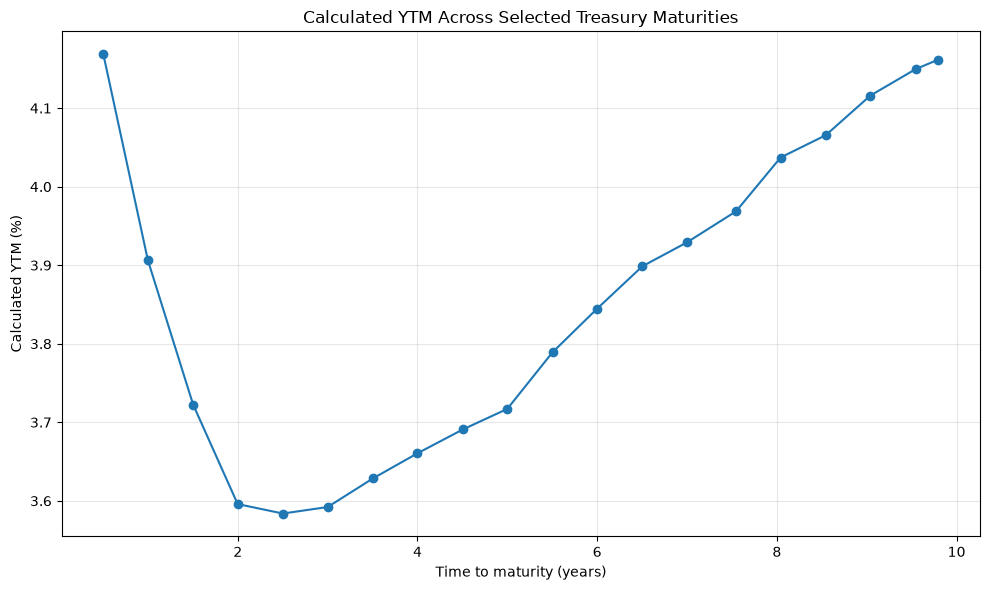

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(selected["ttm"], selected["calculated ytm"] * 100, marker="o")
plt.xlabel("Time to maturity (years)")
plt.ylabel("Calculated YTM (%)")
plt.title("Calculated YTM Across Selected Treasury Maturities")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.1 Provided yields across maturities

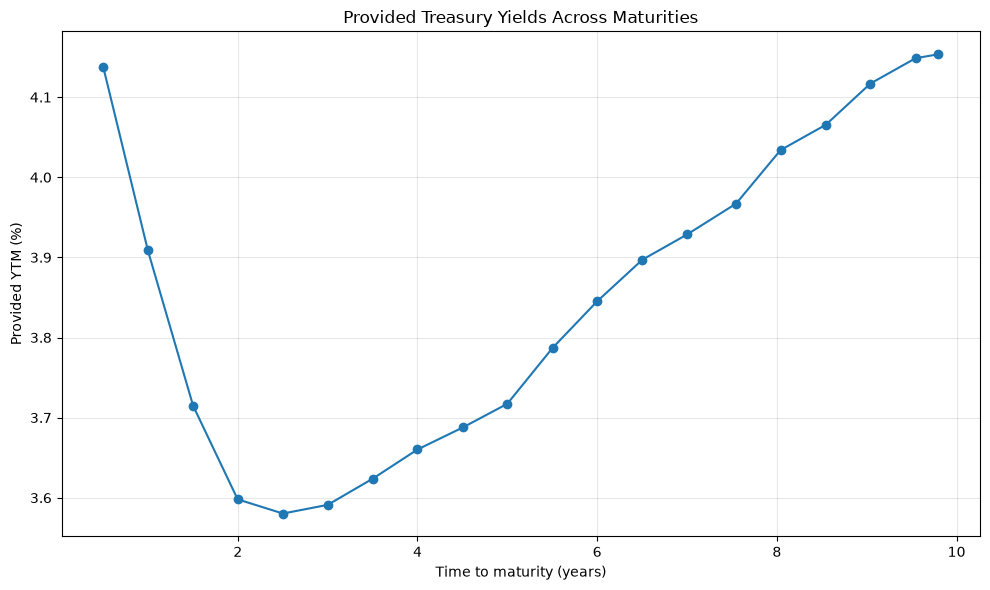

In [46]:
# Use the selected quotes tab
nominal = selected[
    ~selected["type"].isin(["TIPS note", "TIPS bond"])
].copy()

provided_curve = nominal.dropna(subset=["ytm"]).sort_values("ttm")

plt.figure(figsize=(10, 6))
plt.plot(
    provided_curve["ttm"],
    provided_curve["ytm"] * 100,
    marker="o"
)

plt.xlabel("Time to maturity (years)")
plt.ylabel("Provided YTM (%)")
plt.title("Provided Treasury Yields Across Maturities")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2 Calculated YTMs for nominal coupon bonds

In [47]:
nominal = selected[
    ~selected["type"].isin(["TIPS note", "TIPS bond"])
].copy()

comparable = nominal.dropna(subset=["ytm"])

print(
    f"Mean absolute error: "
    f"{comparable['absolute error (bps)'].mean():.3f} bps"
)

print(
    f"Median absolute error: "
    f"{comparable['absolute error (bps)'].median():.3f} bps"
)

print(
    f"Maximum absolute error: "
    f"{comparable['absolute error (bps)'].max():.3f} bps"
)

Mean absolute error: 0.380 bps
Median absolute error: 0.184 bps
Maximum absolute error: 3.147 bps


In [48]:
missing_reported_ytm = nominal[nominal["ytm"].isna()][
    [
        "KYTREASNO",
        "type",
        "ttm",
        "cpn rate",
        "price",
        "calculated ytm"
    ]
]

if missing_reported_ytm.empty:
    print("There are no nominal issues with missing YTM in the selected quotes tab.")
else:
    display(missing_reported_ytm.round(6))

There are no nominal issues with missing YTM in the selected quotes tab.


## 2.3 Treasury-bill discount yields

In [27]:
# 2.3 Treasury-bill discount yields

# Use the full quotes sheet because the selected quotes sheet has no T-bills
quotes = pd.read_excel(file_path, sheet_name="quotes")

# Identify Treasury bills
bills = quotes[
    quotes["type"].eq("bill") | quotes["cpn rate"].eq(0)
].copy()

# Calculate the exact number of days remaining until maturity
bills["days to maturity"] = (
    pd.to_datetime(bills["maturity date"])
    - pd.to_datetime(bills["quote date"])
).dt.days

# Bank discount yield formula
bills["discount yield"] = (
    (100 - bills["price"]) / 100
    * 360 / bills["days to maturity"]
)

# Display the results
bills[
    [
        "KYTREASNO",
        "maturity date",
        "days to maturity",
        "price",
        "discount yield"
    ]
].round(
    {
        "price": 6,
        "discount yield": 6
    }
)

/var/folders/3q/j41srnrn1bxbfzf45m59yd5w0000gn/T/ipykernel_70113/3467441913.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(6)


,KYTREASNO,maturity date,days to maturity,price,discount yield
0,208300,2025-05-01,1,100.000000,0.000000
1,208327,2025-05-06,6,99.941681,0.034992
2,208311,2025-05-08,8,99.918333,0.036750
3,208336,2025-05-13,13,99.859667,0.038862
5,208226,2025-05-15,15,99.836278,0.039293
7,208337,2025-05-20,20,99.776750,0.040185
8,208312,2025-05-22,22,99.752795,0.040452
9,208338,2025-05-27,27,99.695092,0.040654
10,208313,2025-05-29,29,99.672182,0.040695
14,208339,2025-06-03,34,99.614007,0.040870


The Treasury-bill discount yield is calculated as

$$
\text{Discount yield}
=
\frac{100-P}{100}
\times
\frac{360}{\text{days to maturity}}
$$

where \(P\) is the Treasury bill's price and the face value is 100.
